In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load data
california = fetch_california_housing(as_frame=True)
df = pd.concat([california.data, california.target.rename("median_house_value")], axis=1)

# Preview
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,median_house_value
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
from sklearn.model_selection import train_test_split

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [3]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [4]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Squared Error: 0.56
R² Score: 0.58


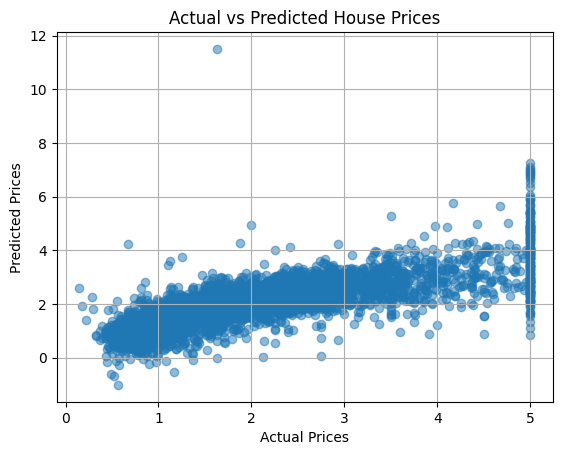

In [5]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.show()


In [6]:
# Sample input: customize these values
user_input = {
    "MedInc": 5.0,         # Median income in block group
    "HouseAge": 20.0,      # Median house age
    "AveRooms": 6.0,       # Average number of rooms
    "AveBedrms": 1.0,      # Average number of bedrooms
    "Population": 800.0,   # Block group population
    "AveOccup": 3.0,       # Average household occupancy
    "Latitude": 34.0,      # Latitude coordinate
    "Longitude": -118.0    # Longitude coordinate
}

# Convert to DataFrame
input_df = pd.DataFrame([user_input])

# Predict
predicted_price = model.predict(input_df)[0]
print(f"Estimated Median House Value: ${predicted_price * 100000:.2f}")


Estimated Median House Value: $235019.13
